# Roman Urdu Scam / Fraud SMS Detector - Dataset Exploration

**Partner A - Data & Preprocessing Lead**

This notebook explores the raw dataset and documents the preprocessing results.
Every number is calculated from the data, so the notebook stays correct if the
dataset changes.

Sections:
1. Load the raw dataset
2. Inspect the raw columns (before any cleaning)
3. Data quality problems found
4. Run the preprocessing pipeline
5. Dataset statistics and charts
6. Before / after preprocessing examples
7. Word analysis
8. Template duplication (data-leakage check)

In [2]:
import sys
from pathlib import Path

# Make the project root importable when the notebook runs from notebooks/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd

from preprocessing import config
from preprocessing.data_loader import load_dataset

pd.set_option("display.max_colwidth", 90)
print("Project root:", PROJECT_ROOT)

Project root: d:\Semester-6\ML\project-scam-detactor\roman-urdu-scam-detector


## 1. Load the raw dataset

In [3]:
raw = load_dataset()

print("Shape :", raw.shape)
print("Columns:", list(raw.columns))
raw.head()

Shape : (549, 3)
Columns: ['msg', 'status', 'Authentic/Synthetic']


,msg,status,Authentic/Synthetic
0,"Roz khelain, roz jeetain! Play&Win se rozana upto 500MBs free data Jeetne ka mauqa paa...",scam,authentic
1,IMDAD program apne is sy 8171 py sms kiya tha Apki Rs.12000 ki Emdad Manzor hoihe Ap M...,scam,authentic
2,10GB FREE Aap keliye! MyTelenor App pehli dafa install karo aur fore claim karo. Click...,scam,authentic
3,"BENAZIRE:Ehsaas.program.ki.taraf se apko Rs.75,600 mubarek ho apka ye number [Number] ...",scam,authentic
4,10GB FREE Aap keliye! MyTelenor App pehli dafa install karo aur fore claim karo. Click...,scam,authentic


## 2. Inspect the raw columns (before any cleaning)

Note the inconsistent capitalisation and the trailing space in one label.
`repr()` is used so hidden whitespace is visible.

In [4]:
print("=== status (the ML target) ===")
for value, count in raw[config.LABEL_COLUMN].value_counts(dropna=False).items():
    print(f"  {value!r:<14} -> {count}")

print("\n=== Authentic/Synthetic (reporting only, NOT the target) ===")
for value, count in raw[config.SOURCE_COLUMN].value_counts(dropna=False).items():
    print(f"  {value!r:<14} -> {count}")

=== status (the ML target) ===
  'Scam'         -> 273
  'Genuine'      -> 266
  'scam'         -> 9
  'Genuine '     -> 1

=== Authentic/Synthetic (reporting only, NOT the target) ===
  'Synthetic'    -> 500
  'Authentic'    -> 40
  'authentic'    -> 9


## 3. Data quality problems found

`validate_dataset()` inspects the data without changing it.

In [5]:
from preprocessing.validator import validate_dataset

validation = validate_dataset(raw)
pd.Series(validation).to_frame("value")

,value
initial_records,549
missing_messages,0
empty_messages,1
missing_labels,0
invalid_labels,0
duplicate_messages,4
conflicting_label_groups,1
valid_records_after_cleaning,543


In [6]:
# The whitespace-only message, and the message that carries two different labels.
blank = raw[raw[config.TEXT_COLUMN].astype(str).str.strip() == ""]
print(f"Whitespace-only messages: {len(blank)}")
display(blank)

key = raw[config.TEXT_COLUMN].astype(str).str.strip().str.lower()
labels_per_message = raw.assign(_k=key).groupby("_k")[config.LABEL_COLUMN].nunique()
conflicting = set(labels_per_message[labels_per_message > 1].index)
print(f"\nMessages with contradictory labels: {len(conflicting)}")
display(raw[key.isin(conflicting)])

Whitespace-only messages: 1


,msg,status,Authentic/Synthetic
48,,Scam,Authentic



Messages with contradictory labels: 1


,msg,status,Authentic/Synthetic
20,Jazz Caller Name service se Caller ka naam call uthane se pehle screen pr dekhen. (Rs....,Genuine,Authentic
23,Jazz Caller Name service se Caller ka naam call uthane se pehle screen pr dekhen. (Rs....,Scam,Authentic


## 4. Run the preprocessing pipeline

This performs every step: validation, label normalization, duplicate removal,
text cleaning, Roman Urdu normalization, stopword removal, the 80/20 split and
TF-IDF feature extraction.

In [7]:
from preprocessing import run_preprocessing_pipeline

results = run_preprocessing_pipeline(save_outputs=True, show_examples=False)

cleaned = results["cleaned_dataframe"]
report = results["report"]

[INFO] Loading dataset...
[INFO] Dataset loaded successfully.
[INFO] Initial records: 549
[INFO] Validating dataset...
[INFO]   Initial records: 549
[INFO]   Missing messages: 0
[INFO]   Empty messages: 1
[INFO]   Missing labels: 0
[INFO]   Invalid labels: 0
[INFO]   Duplicate messages: 4
[INFO]   Conflicting label groups: 1
[INFO]   Valid records after cleaning: 543
[INFO] Normalizing labels...
[INFO] Fixed 10 inconsistent label spelling(s): {'scam': 9, 'Genuine ': 1}
[INFO] Removing invalid rows (missing / empty messages, bad labels)...
[WARNING] 1 empty message(s) removed.
[INFO] Records after removing invalid rows: 548
[INFO] Removing duplicates...
[WARNING] 1 message(s) appear with MORE THAN ONE label (contradictory ground truth).
[WARNING]   labels=['Genuine', 'Scam'] copies=2 :: Jazz Caller Name service se Caller ka naam call uthane se pehle screen pr dekhen. (Rs.3.2/
[WARNING] Policy='drop': removed all 2 copies of contradictory message(s).
[INFO] Removed 3 duplicate message(s)

## 5. Dataset statistics and charts

In [8]:
stats = report["statistics"]

summary = pd.DataFrame(
    {
        "Metric": [
            "Initial records",
            "Empty messages removed",
            "Duplicates removed",
            "Contradictory copies dropped",
            "Final records",
            "Scam",
            "Genuine",
            "Authentic",
            "Synthetic",
            "Training records",
            "Testing records",
            "TF-IDF features",
        ],
        "Value": [
            report["initial_records"],
            report["invalid_row_removal"]["empty_messages_removed"],
            report["duplicate_removal"]["duplicates_removed"],
            report["duplicate_removal"]["conflicting_rows_removed"],
            report["final_records"],
            stats["scam_count"],
            stats["genuine_count"],
            stats["authentic_count"],
            stats["synthetic_count"],
            report["split"]["training_records"],
            report["split"]["testing_records"],
            report["tfidf"]["n_features"],
        ],
    }
)
summary

,Metric,Value
0,Initial records,549
1,Empty messages removed,1
2,Duplicates removed,3
3,Contradictory copies dropped,2
4,Final records,543
5,Scam,278
6,Genuine,265
7,Authentic,43
8,Synthetic,500
9,Training records,434


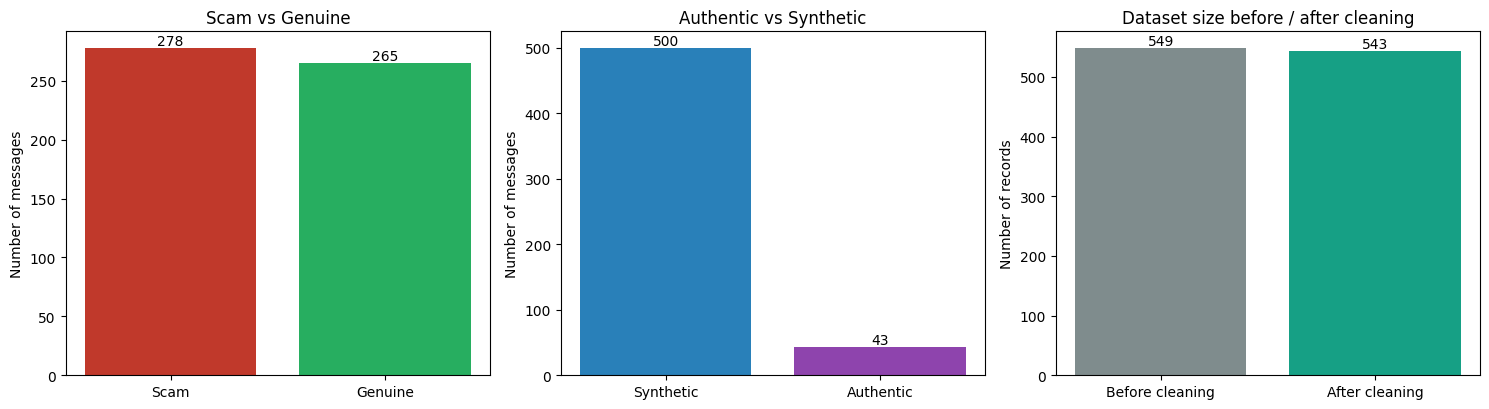

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# --- Chart 1: Scam vs Genuine -------------------------------------------
label_counts = cleaned[config.LABEL_COLUMN].value_counts()
axes[0].bar(label_counts.index, label_counts.values, color=["#c0392b", "#27ae60"])
axes[0].set_title("Scam vs Genuine")
axes[0].set_ylabel("Number of messages")
for i, value in enumerate(label_counts.values):
    axes[0].text(i, value, str(value), ha="center", va="bottom")

# --- Chart 2: Authentic vs Synthetic ------------------------------------
source_counts = cleaned[config.SOURCE_COLUMN].value_counts()
axes[1].bar(source_counts.index, source_counts.values, color=["#2980b9", "#8e44ad"])
axes[1].set_title("Authentic vs Synthetic")
axes[1].set_ylabel("Number of messages")
for i, value in enumerate(source_counts.values):
    axes[1].text(i, value, str(value), ha="center", va="bottom")

# --- Chart 3: dataset size before / after cleaning ----------------------
sizes = [report["initial_records"], report["final_records"]]
axes[2].bar(["Before cleaning", "After cleaning"], sizes, color=["#7f8c8d", "#16a085"])
axes[2].set_title("Dataset size before / after cleaning")
axes[2].set_ylabel("Number of records")
for i, value in enumerate(sizes):
    axes[2].text(i, value, str(value), ha="center", va="bottom")

plt.tight_layout()
plt.show()

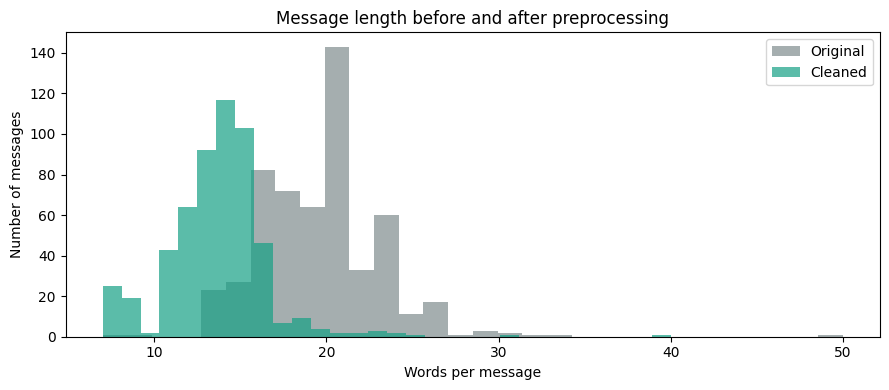

In [10]:
# Message length before and after cleaning.
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(
    cleaned[config.TEXT_COLUMN].astype(str).str.split().str.len(),
    bins=30, alpha=0.7, label="Original", color="#7f8c8d",
)
ax.hist(
    cleaned[config.CLEANED_TEXT_COLUMN].astype(str).str.split().str.len(),
    bins=30, alpha=0.7, label="Cleaned", color="#16a085",
)
ax.set_xlabel("Words per message")
ax.set_ylabel("Number of messages")
ax.set_title("Message length before and after preprocessing")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Before / after preprocessing examples

In [11]:
examples = cleaned.sample(8, random_state=config.RANDOM_STATE)[
    [config.TEXT_COLUMN, config.CLEANED_TEXT_COLUMN, config.LABEL_COLUMN]
]
examples.columns = ["Original SMS", "Cleaned SMS", "Status"]
examples.reset_index(drop=True)

,Original SMS,Cleaned SMS,Status
0,"Warning: Aap ka bijli bill overdue hai, 500 abhi na bheja to bijli 6 ghantay mein kaat...",warning aap bijli bill overdue numtoken abhi bheja bijli numtoken ghantay kaat pay kar...,Scam
1,"Assalam o Alaikum Usman, kal meeting 11 baje hogi office mein, please time pe pohanch ...",assalam alaikum usman kal meeting numtoken baje office please time pohanch,Genuine
2,"Hina, ammi keh rahi hain ke ghar aatay huay doodh le ana, aur haan raat ka khana time ...",hina ammi keh ghar aatay huay doodh ana haan raat khana time,Genuine
3,"Aap ne online survey complete kar li hai, 15,000 reward claim karne ke liye apni bank ...",aap online survey complete li numtoken reward claim liye apni bank details urltoken fi...,Scam
4,"Warning: Aap ka bijli bill overdue hai, 500 abhi na bheja to bijli 6 ghantay mein kaat...",warning aap bijli bill overdue numtoken abhi bheja bijli numtoken ghantay kaat pay kar...,Scam
5,"Reminder: Kal aap ka electricity bill payment due hai amount Rs. 1000, please time pe ...",reminder kal aap electricity bill payment due amount rs numtoken please time pay dein,Genuine
6,UBL se: Aap ka account suspicious activity ki wajah se suspend kar diya gaya hai. Tura...,ubl aap account suspicious activity wajah suspend turant urltoken login karke verify k...,Scam
7,"Aap ka order confirm ho gaya hai, delivery kal shaam tak ho jaye gi. Tracking number: ...",aap order confirm delivery kal shaam tracking number trknumtoken,Genuine


## 7. Word analysis

Which words appear most often in each class? This is descriptive statistics
about the data - model performance analysis belongs to Partner B.

In [12]:
from collections import Counter

scam_words = Counter(
    " ".join(cleaned.loc[cleaned[config.LABEL_COLUMN] == "Scam", config.CLEANED_TEXT_COLUMN]).split()
)
genuine_words = Counter(
    " ".join(cleaned.loc[cleaned[config.LABEL_COLUMN] == "Genuine", config.CLEANED_TEXT_COLUMN]).split()
)

comparison = pd.DataFrame(
    {
        "Top Scam words": [w for w, _ in scam_words.most_common(15)],
        "Scam count": [c for _, c in scam_words.most_common(15)],
        "Top Genuine words": [w for w, _ in genuine_words.most_common(15)],
        "Genuine count": [c for _, c in genuine_words.most_common(15)],
    }
)
comparison

,Top Scam words,Scam count,Top Genuine words,Genuine count
0,numtoken,265,numtoken,255
1,aap,214,aap,196
2,karein,180,rs,114
3,liye,163,karein,91
4,urltoken,147,liye,78
5,number,135,balance,75
6,phonetoken,82,tareekh,65
7,account,69,reminder,64
8,claim,58,bill,64
9,details,54,due,64


In [13]:
# Words that are strongly associated with one class (appear >=4x more often).
scam_only = [w for w, c in scam_words.most_common(200) if genuine_words[w] * 4 < c]
genuine_only = [w for w, c in genuine_words.most_common(200) if scam_words[w] * 4 < c]

print("Strong SCAM indicators   :", scam_only[:20])
print("\nStrong GENUINE indicators:", genuine_only[:20])

Strong SCAM indicators   : ['urltoken', 'number', 'phonetoken', 'claim', 'details', 'abhi', 'apna', 'bhejain', 'verify', 'apni', 'sirf', 'ghantay', 'bijli', 'jayega', 'block', 'wapis', 'activate', 'whatsapp', 'wajah', 'urgent']

Strong GENUINE indicators: ['rs', 'balance', 'tareekh', 'reminder', 'due', 'amount', 'kal', 'time', 'mahine', 'shortcodetoken', 'dial', 'mahana', 'statement', 'dekhne', 'open', 'transaction', 'successful', 'naya', 'check', 'please']


## 8. Template duplication (data-leakage check)

Most synthetic messages come from a small number of templates where only the
amount and the link change. After cleaning, those messages become **identical**
strings. If a message and its twin end up on opposite sides of the train/test
split, the model is graded on text it has already memorized, and the accuracy
looks better than it really is.

The pipeline measures this so it can be reported honestly.

In [14]:
overlap = report["train_test_overlap"]
templates = report["cleaned_text_duplicates"]

print(f"Unique cleaned texts          : {templates['unique_cleaned_texts']}")
print(f"Rows sharing a cleaned text   : {templates['cleaned_duplicate_rows']}")
print(f"Template groups               : {templates['cleaned_duplicate_groups']}")
print(f"Largest template group        : {templates['largest_template_group']} messages")
print()
print(f"Test messages                 : {overlap['test_records']}")
print(f"...also present in training   : {overlap['test_records_also_in_train']}"
      f" ({overlap['test_overlap_percent']}%)")

Unique cleaned texts          : 238
Rows sharing a cleaned text   : 305
Template groups               : 60
Largest template group        : 18 messages

Test messages                 : 109
...also present in training   : 75 (68.81%)


In [15]:
# The biggest template group: same cleaned text, different amounts and links.
biggest = cleaned[config.CLEANED_TEXT_COLUMN].value_counts().idxmax()
group = cleaned[cleaned[config.CLEANED_TEXT_COLUMN] == biggest]

print(f"This ONE cleaned text covers {len(group)} original messages:\n")
print(f"  CLEANED: {biggest}\n")
for message in group[config.TEXT_COLUMN].head(5):
    print(f"  raw: {message}")

This ONE cleaned text covers 18 original messages:

  CLEANED: aap online survey complete li numtoken reward claim liye apni bank details urltoken fill karein

  raw: Aap ne online survey complete kar li hai, 100,000 reward claim karne ke liye apni bank details tinyurl.com/win-prize2 pe fill karein.
  raw: Aap ne online survey complete kar li hai, 50,000 reward claim karne ke liye apni bank details pta-verify.online pe fill karein.
  raw: Aap ne online survey complete kar li hai, 5000 reward claim karne ke liye apni bank details meezan-alert.com pe fill karein.
  raw: Aap ne online survey complete kar li hai, 15,000 reward claim karne ke liye apni bank details jazzcash-verify.info pe fill karein.
  raw: Aap ne online survey complete kar li hai, 15,000 reward claim karne ke liye apni bank details tinyurl.com/win-prize2 pe fill karein.


For a leakage-free evaluation, run the pipeline in strict mode, which also drops
duplicates of the cleaned text:

```bash
python run_preprocessing.py --strict
```

That reduces the dataset to the unique cleaned messages and brings the
train/test overlap to **0%**. Reporting both numbers - the full-dataset result
and the strict result - is the most honest way to present this project.

## 9. Handover to Partner B

The pipeline returns everything Partner B needs:

```python
X_train_tfidf    = results["X_train_tfidf"]
X_test_tfidf     = results["X_test_tfidf"]
y_train          = results["y_train"]
y_test           = results["y_test"]
tfidf_vectorizer = results["tfidf_vectorizer"]
```

In [16]:
print("X_train_tfidf   :", results["X_train_tfidf"].shape)
print("X_test_tfidf    :", results["X_test_tfidf"].shape)
print("y_train         :", len(results["y_train"]), "labels")
print("y_test          :", len(results["y_test"]), "labels")
print("tfidf_vectorizer:", type(results["tfidf_vectorizer"]).__name__,
      "with", len(results["tfidf_vectorizer"].vocabulary_), "features")
print("\nSaved files:")
for name, path in report["output_files"].items():
    print(f"  {name:22s} {path}")

X_train_tfidf   : (434, 1656)
X_test_tfidf    : (109, 1656)
y_train         : 434 labels
y_test          : 109 labels
tfidf_vectorizer: TfidfVectorizer with 1656 features

Saved files:
  cleaned_dataset        D:\Semester-6\ML\project-scam-detactor\roman-urdu-scam-detector\data\processed\cleaned_dataset.csv
  train_dataset          D:\Semester-6\ML\project-scam-detactor\roman-urdu-scam-detector\data\processed\train.csv
  test_dataset           D:\Semester-6\ML\project-scam-detactor\roman-urdu-scam-detector\data\processed\test.csv
  tfidf_vectorizer       D:\Semester-6\ML\project-scam-detactor\roman-urdu-scam-detector\outputs\tfidf_vectorizer.pkl
  preprocessing_report   D:\Semester-6\ML\project-scam-detactor\roman-urdu-scam-detector\outputs\preprocessing_report.json
